# Module 1 — Entraînement du réseau 1D-CNN

Ce notebook entraîne un modèle Deep Learning pour distinguer :

- **1 : polymère / plastique détecté**
- **0 : cellulose / non-plastique**

## Précaution méthodologique

Les lignes d'un même fichier expérimental sont très corrélées. L'évaluation finale est donc réalisée sur des **fichiers complètement absents de l'entraînement**. Les deux fichiers de cellulose sont alternés entre les deux plis d'évaluation.

> Comme il n'existe que deux fichiers non plastiques indépendants, les résultats constituent une preuve de concept et non une validation scientifique définitive.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score,
    balanced_accuracy_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver le dossier data.")

DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'module1_spectra_binary.npz'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module1' / 'training'
MODELS_DIR = PROJECT_ROOT / 'models' / 'module1'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow :', tf.__version__)
print('Dataset trouvé :', DATASET_PATH.exists())
assert DATASET_PATH.exists(), f'Dataset introuvable : {DATASET_PATH}'

TensorFlow : 2.21.0
Dataset trouvé : True


## 1. Chargement des données

In [2]:
data = np.load(DATASET_PATH, allow_pickle=True)

X = data['X'].astype(np.float32)
y = data['y'].astype(np.int32)
groups = data['groups'].astype(str)
families = data['families'].astype(str)
wavenumbers = data['wavenumbers'].astype(np.float32)

print('X :', X.shape)
print('y :', y.shape)
print('Fichiers indépendants :', len(np.unique(groups)))
print('Polymères :', int((y == 1).sum()))
print('Non-plastiques :', int((y == 0).sum()))
print('Fichiers cellulose :', np.unique(groups[y == 0]).tolist())

assert len(np.unique(groups[y == 0])) == 2, (
    "Ce notebook attend exactement deux fichiers cellulose."
)

X : (7544, 415)
y : (7544,)
Fichiers indépendants : 29
Polymères : 7022
Non-plastiques : 522
Fichiers cellulose : ['DF_20231109 cellulose NRC 150-750C.csv', 'DF_20231110 cellulose sigma 150-750C.csv']


## 2. Création de deux plis séparés par fichier

Chaque pli contient un fichier cellulose différent dans le test. Les fichiers polymères sont également divisés entre les deux plis. Ainsi, aucune ligne d'un fichier de test n'apparaît dans l'entraînement.

In [3]:
negative_groups = sorted(np.unique(groups[y == 0]).tolist())
positive_groups = sorted(np.unique(groups[y == 1]).tolist())

rng = np.random.default_rng(SEED)
positive_groups_shuffled = positive_groups.copy()
rng.shuffle(positive_groups_shuffled)
positive_halves = np.array_split(positive_groups_shuffled, 2)

folds = []
for fold_index in range(2):
    test_groups = set(positive_halves[fold_index].tolist() + [negative_groups[fold_index]])
    train_groups = set(np.unique(groups).tolist()) - test_groups

    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    test_idx = np.where(np.isin(groups, list(test_groups)))[0]

    folds.append((train_idx, test_idx, train_groups, test_groups))

    print(f'Pli {fold_index + 1}')
    print('  Fichiers train :', len(train_groups))
    print('  Fichiers test  :', len(test_groups))
    print('  Train classes  :', np.bincount(y[train_idx]))
    print('  Test classes   :', np.bincount(y[test_idx]))
    print('  Cellulose test :', negative_groups[fold_index])
    print()

    assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
    assert set(np.unique(y[train_idx])) == {0, 1}
    assert set(np.unique(y[test_idx])) == {0, 1}

Pli 1
  Fichiers train : 14
  Fichiers test  : 15
  Train classes  : [ 261 3379]
  Test classes   : [ 261 3643]
  Cellulose test : DF_20231109 cellulose NRC 150-750C.csv

Pli 2
  Fichiers train : 15
  Fichiers test  : 14
  Train classes  : [ 261 3643]
  Test classes   : [ 261 3379]
  Cellulose test : DF_20231110 cellulose sigma 150-750C.csv



## 3. Architecture du réseau 1D-CNN

In [4]:
def build_model(n_features: int) -> tf.keras.Model:
    model = Sequential([
        Input(shape=(n_features, 1)),
        Conv1D(32, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(96, kernel_size=3, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dense(48, activation='relu'),
        Dropout(0.35),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

test_model = build_model(X.shape[1])
test_model.summary()
del test_model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 415, 32)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 415, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 207, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 207, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 207, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 103, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 103, 96)             │          18,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 96)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 48)                  │           4,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,177 (133.50 KB)

 Trainable params: 33,985 (132.75 KB)

 Non-trainable params: 192 (768.00 B)

## 4. Entraînement et évaluation

La validation interne sert uniquement à contrôler l'apprentissage. La mesure principale reste le test sur des fichiers totalement indépendants.


ENTRAÎNEMENT DU PLI 1
Poids des classes : {0: 6.968468468468468, 1: 0.5386490250696379}
Epoch 1/35
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8151 - auc: 0.9239 - loss: 0.3973 - precision: 0.9923 - recall: 0.8071 - val_accuracy: 0.9414 - val_auc: 0.9720 - val_loss: 0.5446 - val_precision: 0.9473 - val_recall: 0.9921 - learning_rate: 0.0010
Epoch 2/35
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9153 - auc: 0.9793 - loss: 0.1835 - precision: 0.9970 - recall: 0.9116 - val_accuracy: 0.9505 - val_auc: 0.9771 - val_loss: 0.5995 - val_precision: 0.9918 - val_recall: 0.9546 - learning_rate: 0.0010
Epoch 3/35
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9551 - auc: 0.9927 - loss: 0.1156 - precision: 0.9982 - recall: 0.9533 - val_accuracy: 0.9487 - val_auc: 0.9859 - val_loss: 0.5587 - val_precision: 0.9597 - val_recall: 0.9862 - learning_rate: 0.0010
Epoch 4/35
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9842 - auc: 0.9971 - loss: 0.0573 - precision: 0.99

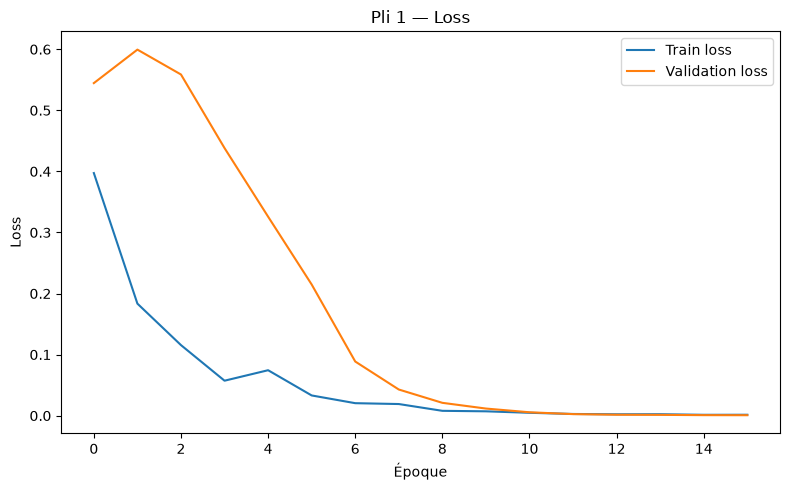

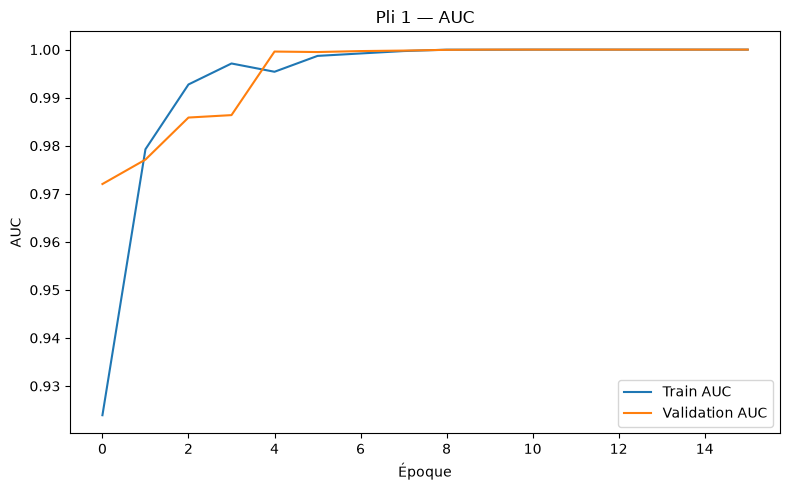

<Figure size 600x500 with 0 Axes>

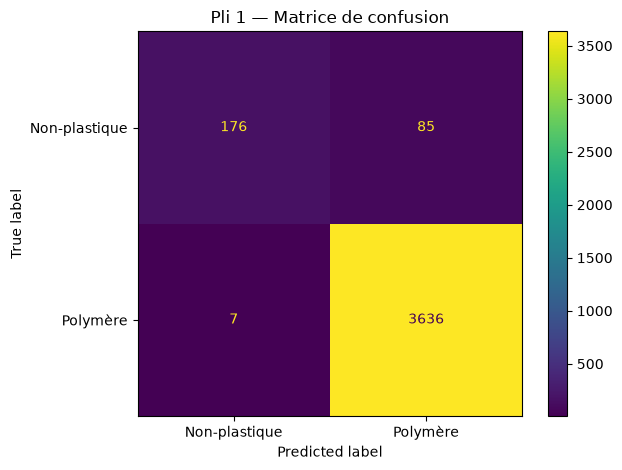

<Figure size 600x500 with 0 Axes>

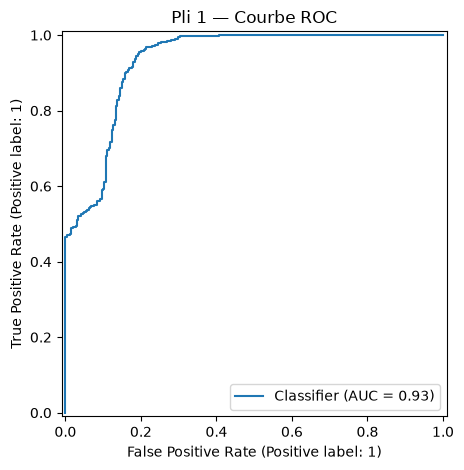


ENTRAÎNEMENT DU PLI 2
Poids des classes : {0: 7.472972972972973, 1: 0.5358527131782945}
Epoch 1/35
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8062 - auc: 0.8523 - loss: 0.4835 - precision: 0.9782 - recall: 0.8104 - val_accuracy: 0.9334 - val_auc: 0.4683 - val_loss: 0.6589 - val_precision: 0.9334 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/35
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9376 - auc: 0.9473 - loss: 0.3089 - precision: 0.9872 - recall: 0.9454 - val_accuracy: 0.4829 - val_auc: 0.5151 - val_loss: 0.6665 - val_precision: 0.9326 - val_recall: 0.4808 - learning_rate: 0.0010
Epoch 3/35
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9578 - auc: 0.9781 - loss: 0.2157 - precision: 0.9904 - recall: 0.9641 - val_accuracy: 0.1297 - val_auc: 0.9572 - val_loss: 0.8563 - val_precision: 1.0000 - val_recall: 0.0676 - learning_rate: 0.0010
Epoch 4/35
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9717 - auc: 0.9763 - loss: 0.1194 - precision: 0.99

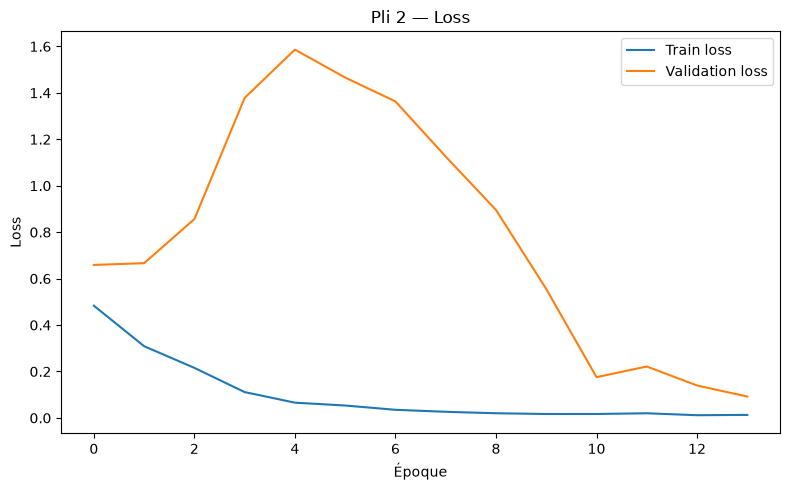

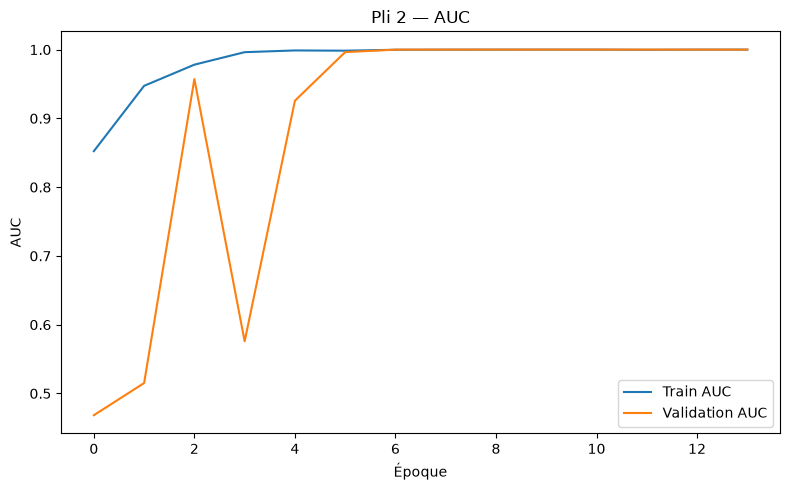

<Figure size 600x500 with 0 Axes>

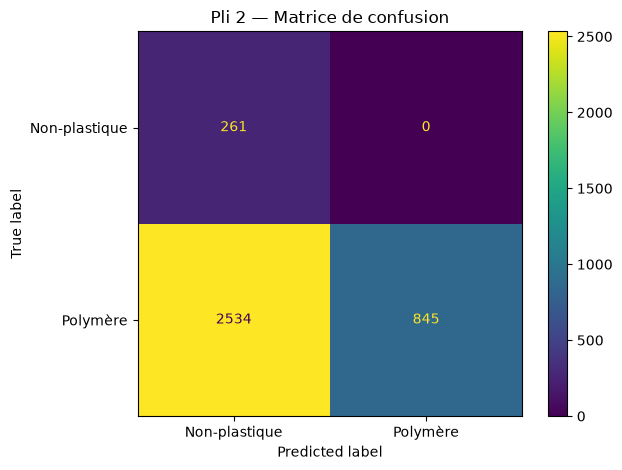

<Figure size 600x500 with 0 Axes>

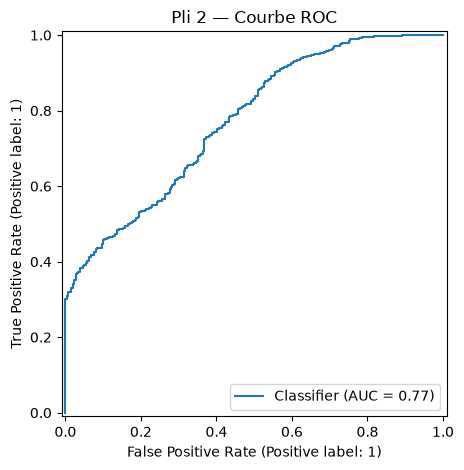


✅ Les deux plis ont été entraînés et évalués.


In [5]:
all_metrics = []
all_predictions = []

for fold_number, (train_idx, test_idx, train_groups, test_groups) in enumerate(folds, start=1):
    print('\n' + '=' * 70)
    print(f'ENTRAÎNEMENT DU PLI {fold_number}')
    print('=' * 70)

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train_all, y_test = y[train_idx], y[test_idx]

    # Mise à l'échelle apprise uniquement sur le train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_test_scaled = scaler.transform(X_test_raw).astype(np.float32)

    # Validation interne stratifiée par ligne, uniquement pour Early Stopping.
    # Le test final reste entièrement séparé par fichier.
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_scaled,
        y_train_all,
        test_size=0.15,
        stratify=y_train_all,
        random_state=SEED + fold_number
    )

    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight='balanced', classes=classes, y=y_train
    )
    class_weight = {0: float(weights[0]), 1: float(weights[1])}
    print('Poids des classes :', class_weight)

    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]
    X_test_cnn = X_test_scaled[..., np.newaxis]

    model = build_model(X.shape[1])

    callbacks = [
        EarlyStopping(
            monitor='val_auc', mode='max', patience=6,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=1
        )
    ]

    history = model.fit(
        X_train_cnn, y_train,
        validation_data=(X_val_cnn, y_val),
        epochs=35,
        batch_size=64,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    probabilities = model.predict(X_test_cnn, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        'fold': fold_number,
        'accuracy': accuracy_score(y_test, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, zero_division=0),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'f1': f1_score(y_test, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_test, probabilities),
        'test_files': len(test_groups),
        'test_rows': len(test_idx)
    }
    all_metrics.append(metrics)

    fold_predictions = pd.DataFrame({
        'fold': fold_number,
        'group': groups[test_idx],
        'family': families[test_idx],
        'true_label': y_test,
        'probability_polymer': probabilities,
        'predicted_label': predictions
    })
    all_predictions.append(fold_predictions)

    print('\nMétriques du pli :')
    for key, value in metrics.items():
        print(f'{key:20s}: {value}')

    print('\nRapport de classification :')
    print(classification_report(
        y_test, predictions,
        target_names=['Non-plastique', 'Polymère'],
        digits=4,
        zero_division=0
    ))

    # Courbes d'apprentissage
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.title(f'Pli {fold_number} — Loss')
    plt.xlabel('Époque')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'fold_{fold_number}_loss.png', dpi=160, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title(f'Pli {fold_number} — AUC')
    plt.xlabel('Époque')
    plt.ylabel('AUC')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'fold_{fold_number}_auc.png', dpi=160, bbox_inches='tight')
    plt.show()

    # Matrice de confusion
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        display_labels=['Non-plastique', 'Polymère'],
        values_format='d'
    )
    plt.title(f'Pli {fold_number} — Matrice de confusion')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'fold_{fold_number}_confusion_matrix.png', dpi=160, bbox_inches='tight')
    plt.show()

    # Courbe ROC
    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, probabilities)
    plt.title(f'Pli {fold_number} — Courbe ROC')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'fold_{fold_number}_roc.png', dpi=160, bbox_inches='tight')
    plt.show()

    model.save(MODELS_DIR / f'module1_1dcnn_fold_{fold_number}.keras')
    joblib.dump(scaler, MODELS_DIR / f'module1_scaler_fold_{fold_number}.joblib')

print('\n✅ Les deux plis ont été entraînés et évalués.')

## 5. Résumé final des performances

In [6]:
metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(metrics_df)

metric_columns = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'roc_auc']
summary = pd.DataFrame({
    'moyenne': metrics_df[metric_columns].mean(),
    'ecart_type': metrics_df[metric_columns].std(ddof=0)
})

print('Résumé moyen des deux plis :')
display(summary)

metrics_df.to_csv(RESULTS_DIR / 'metrics_par_pli.csv', index=False, encoding='utf-8-sig')
summary.to_csv(RESULTS_DIR / 'metrics_resume.csv', encoding='utf-8-sig')
predictions_df.to_csv(RESULTS_DIR / 'predictions_group_holdout.csv', index=False, encoding='utf-8-sig')

print('✅ Métriques et prédictions sauvegardées dans :', RESULTS_DIR)

,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,test_files,test_rows
0,1,0.976434,0.836204,0.977157,0.998079,0.987507,0.932961,15,3904
1,2,0.303846,0.625037,1.000000,0.250074,0.400095,0.772336,14,3640


Résumé moyen des deux plis :


,moyenne,ecart_type
accuracy,0.640140,0.336294
balanced_accuracy,0.730620,0.105584
precision,0.988578,0.011422
recall,0.624076,0.374002
f1,0.693801,0.293706
roc_auc,0.852649,0.080312


✅ Métriques et prédictions sauvegardées dans : C:\Users\elasr\OneDrive\Desktop\hind\results\module1\training


## 6. Entraînement du modèle final pour l'application

Après l'évaluation, un modèle final est entraîné sur toutes les données disponibles. Ce modèle sera utilisé par l'interface Streamlit. Les métriques scientifiques à présenter restent celles des deux plis précédents.

In [7]:
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X).astype(np.float32)

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_all_scaled, y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

final_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=y_final_train
)
final_class_weight = {0: float(final_weights[0]), 1: float(final_weights[1])}

final_model = build_model(X.shape[1])
final_history = final_model.fit(
    X_final_train[..., np.newaxis], y_final_train,
    validation_data=(X_final_val[..., np.newaxis], y_final_val),
    epochs=35,
    batch_size=64,
    class_weight=final_class_weight,
    callbacks=[
        EarlyStopping(
            monitor='val_auc', mode='max', patience=6,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=1
        )
    ],
    verbose=1
)

final_model_path = MODELS_DIR / 'module1_1dcnn_final.keras'
final_scaler_path = MODELS_DIR / 'module1_scaler_final.joblib'
metadata_path = MODELS_DIR / 'module1_metadata.json'

final_model.save(final_model_path)
joblib.dump(final_scaler, final_scaler_path)

metadata = {
    'task': 'binary_polymer_detection',
    'negative_class': 'cellulose_non_plastique',
    'positive_class': 'polymer_plastic',
    'threshold': 0.5,
    'n_features': int(X.shape[1]),
    'wavenumbers': wavenumbers.tolist(),
    'important_limitation': (
        'Only two independent cellulose files were available. '
        'The model is a proof of concept and requires more negative samples.'
    )
}
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('✅ Modèle final :', final_model_path)
print('✅ Scaler final :', final_scaler_path)
print('✅ Métadonnées :', metadata_path)

Epoch 1/35
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7993 - auc: 0.9033 - loss: 0.3981 - precision: 0.9857 - recall: 0.7959 - val_accuracy: 0.9311 - val_auc: 0.5752 - val_loss: 0.6342 - val_precision: 0.9311 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/35
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9116 - auc: 0.9691 - loss: 0.2347 - precision: 0.9929 - recall: 0.9115 - val_accuracy: 0.9355 - val_auc: 0.4821 - val_loss: 0.5423 - val_precision: 0.9352 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/35
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9462 - auc: 0.9823 - loss: 0.1716 - precision: 0.9937 - recall: 0.9482 - val_accuracy: 0.9470 - val_auc: 0.7961 - val_loss: 0.5177 - val_precision: 0.9469 - val_recall: 0.9991 - learning_rate: 0.0010
Epoch 4/35
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9612 - auc: 0.9924 - loss: 0.1124 - precision: 0.9965 - recall: 0.9616 - val_accuracy: 0.9691 - val_auc: 0.9630 - val_loss: 0.4090 

## Fichiers attendus

Dans `models/module1/` :

- `module1_1dcnn_fold_1.keras`
- `module1_1dcnn_fold_2.keras`
- `module1_1dcnn_final.keras`
- `module1_scaler_final.joblib`
- `module1_metadata.json`

Dans `results/module1/training/` :

- métriques par pli ;
- résumé des métriques ;
- prédictions ;
- matrices de confusion ;
- courbes ROC ;
- courbes d'apprentissage.